## Generate Virginia pnode names and ids to subset PJM lmp data

1. Load sample PJM CSV: data/raw/usa_data/rt_hrl_lmps.csv
    - Find all unique pnode names and ids and subset these. Find also all unique zone values and unique type values

2. Load:
 - us states boundaries data: data/raw/usa_data/tl_2025_us_state/tl_2025_us_state.shp
 - electric substations data: data/raw/usa_data/electricSubstations/Shapefile/electric_substations_hifld_v4_FieldMods.shp
 - electric utility territories data: data/raw/usa_data/electricUtilityTerritories/Shapefile/Electric_Retail_Service_Territories_CustomFields.shp

3. Check which electric utilities have coverage within the state geographic boundaries of virginia. Use this to filter by zones in the PJM data later. 

4. Which substations are in virginia? Subset these substations. Filter out irrelevant ones (ie. unknown name), 

5. Match these substations to the pnodes in the PJM data by name. Use fuzzy matching and then use AI + manual checks to sort the rest 

- PJM pnode id $\neq$ HIFLD_ID

6. Merge. Then should have a file that includes(joined by the matched pnode names). 
    From substation data: HIFLD_Name; HIFLD_ID; city; zip; type; county; countyfips;StateShort;	StateFull; latitude; longitude
    From PJM data: pnode_id; pnode_name; type; zone

    - Summarise the PJM data type and zone unique values (used for data download later)

7. Then: subset this only to pnode_id

In [1]:
import sys
from pathlib import Path
import pandas as pd
import geopandas as gpd

### Load and Inspect Sample LMP Hourly Data (data from one day)

In [2]:
#Set up file paths
sys.path.append(str(Path.cwd().parents[1] / "src"))
from utils.paths import DATA_DIR

In [3]:
#Check structure of hourly lmp data
sample_hourly_lmp = pd.read_csv(DATA_DIR / "raw" / "usa_data" / "rt_hrl_lmps.csv")
print(sample_hourly_lmp.columns.tolist())


['datetime_beginning_utc', 'datetime_beginning_ept', 'pnode_id', 'pnode_name', 'voltage', 'equipment', 'type', 'zone', 'system_energy_price_rt', 'total_lmp_rt', 'congestion_price_rt', 'marginal_loss_price_rt', 'row_is_current', 'version_nbr']


In [4]:
#Inspect
sample_hourly_lmp.head()

,datetime_beginning_utc,datetime_beginning_ept,pnode_id,pnode_name,voltage,equipment,type,zone,system_energy_price_rt,total_lmp_rt,congestion_price_rt,marginal_loss_price_rt,row_is_current,version_nbr
0,3/15/2026 4:00:00 AM,3/15/2026 12:00:00 AM,1,PJM-RTO,NaN,NaN,ZONE,NaN,21.69,21.710752,0.013905,0.011014,True,1
1,3/15/2026 4:00:00 AM,3/15/2026 12:00:00 AM,3,MID-ATL/APS,NaN,NaN,ZONE,NaN,21.69,22.857885,0.689557,0.482495,True,1
2,3/15/2026 4:00:00 AM,3/15/2026 12:00:00 AM,48592,ALDENE,230 KV,T-10,LOAD,PSEG,21.69,23.920000,1.500000,0.730000,True,1
3,3/15/2026 4:00:00 AM,3/15/2026 12:00:00 AM,48593,ALDENE,230 KV,T-20,LOAD,PSEG,21.69,23.920000,1.500000,0.730000,True,1
4,3/15/2026 4:00:00 AM,3/15/2026 12:00:00 AM,48594,ATHENIA,26 KV,AB GRP,LOAD,PSEG,21.69,24.460000,1.790000,0.980000,True,1


In [5]:
#Identify unique zone and type values
# Unique zone values
unique_zones = sorted(sample_hourly_lmp["zone"].dropna().unique())

# Unique type values
unique_types = sorted(sample_hourly_lmp["type"].dropna().unique())

print("Zones:", unique_zones)
print("Types:", unique_types)

Zones: ['AECO', 'AEP', 'APS', 'ATSI', 'BGE', 'COMED', 'CPL', 'DAY', 'DEOK', 'DOM', 'DPL', 'DUKE', 'DUQ', 'EKPC', 'EXTERNAL', 'JCPL', 'METED', 'OVEC', 'PECO', 'PENELEC', 'PEPCO', 'PPL', 'PSEG', 'RECO']
Types: ['AGGREGATE', 'EHV', 'EXT', 'GEN', 'HUB', 'INTERFACE', 'LOAD', 'RESIDUAL_METERED_EDC', 'ZONE']


In [6]:
#Filter only by bus nodes (not aggregate or hub)
busnodes = sample_hourly_lmp[sample_hourly_lmp["type"].isin(["EHV", "GEN", "LOAD"])].copy()
print("Bus Type Nodes:", busnodes["type"].unique())

Bus Type Nodes: <ArrowStringArray>
['LOAD', 'GEN', 'EHV']
Length: 3, dtype: str


In [7]:
# Unique pnode names
unique_pnode_names = (sample_hourly_lmp["pnode_name"]
    .dropna()
    .unique()
)

print(unique_pnode_names[:10])  # preview
print("Number of unique pnode names:", len(unique_pnode_names))

<ArrowStringArray>
[    'PJM-RTO', 'MID-ATL/APS',      'ALDENE',     'ATHENIA',    'BELLEVIL',
    'BENNETTS',    'BRIDGEWA',     'CLIF PS',     'FOUNDRY',    'GREENBRO']
Length: 10, dtype: str
Number of unique pnode names: 6656


### Load Substation, Utility, and State Geo Data

In [8]:
#Load
substation_data = gpd.read_file(DATA_DIR / "raw" / "usa_data" / "electricSubstations" / "Shapefile" / "electric_substations_hifld_v4_FieldMods.shp")

utility_data = gpd.read_file(DATA_DIR / "raw" / "usa_data" / "electricUtilityTerritories" / "Shapefile" / "Electric_Retail_Service_Territories_CustomFields.shp")

census_data = gpd.read_file(DATA_DIR / "raw" / "usa_data" / "tl_2025_us_state" / "tl_2025_us_state.shp")

for name, gdf in {"substation": substation_data, "utility": utility_data, "census": census_data}.items():
    print(f"\n--- {name} ---")
    print(gdf.columns.tolist())


--- substation ---
['Name', 'HIFLD_Name', 'HIFLD_ID', 'city', 'City_Prop', 'zip', 'type', 'Type_Prop', 'status', 'Stat_Prop', 'county', 'Count_Prop', 'countyfips', 'StateShort', 'StateFull', 'country', 'latitude', 'longitude', 'naics_code', 'naics_desc', 'source', 'sourcedate', 'val_method', 'val_date', 'lines', 'LineTxt', 'max_volt', 'CurrentMax', 'min_volt', 'CurrentMin', 'max_infer', 'min_infer', 'MinVoltCat', 'geometry']

--- utility ---
['OBJECTID', 'ID', 'NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'TYPE', 'COUNTRY', 'SOURCE', 'SOURCEDATE', 'VAL_DATE', 'WEBSITE', 'REGULATED', 'CNTRL_AREA', 'PLAN_AREA', 'HOLDING_CO', 'SUMMR_PEAK', 'WINTR_PEAK', 'SUMMER_CAP', 'WINTER_CAP', 'NET_GEN', 'PURCHASED', 'NET_EX', 'RETAIL_MWH', 'WSALE_MWH', 'TOTAL_MWH', 'TRANS_MWH', 'CUSTOMERS', 'YEAR', 'Shape__Are', 'Shape__Len', 'NameProp', 'TypeProp', 'CityProp', 'CntrlProp', 'SimpleType', 'HoldCoProp', 'NameFinal', 'TypeAdj', 'geometry']

--- census ---
['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOI

In [9]:
#Check CRSs of all layers to ensure they match
print(census_data.crs)
print(utility_data.crs)
print(substation_data.crs)

EPSG:4269
EPSG:4326
EPSG:3857


In [10]:
#Update all layers to a common CRS - 4326 is fine for filtering/subsetting
TARGET_CRS = "EPSG:4326"

census_data = census_data.to_crs(TARGET_CRS)
utility_data = utility_data.to_crs(TARGET_CRS)
substation_data = substation_data.to_crs(TARGET_CRS)

In [12]:
# Step 1: Filter census data to Virginia
virginia = census_data[census_data["STUSPS"] == "VA"]

# Step 2: Spatial join — find utilities that intersect Virginia
virginia_utilities = gpd.sjoin(
    utility_data,
    virginia[["geometry"]],
    how="inner",
    predicate="intersects"
)

# Filter to only PJM control area
virginia_pjm_utilities = virginia_utilities[
    virginia_utilities["CNTRL_AREA"].str.contains("PJM", na=False)]

print(f"Number of PJM utilities in Virginia: {len(virginia_pjm_utilities)}")
print("\nPJM utility names & control areas:")
print(virginia_pjm_utilities[["NameFinal", "CNTRL_AREA", "STATE"]].drop_duplicates())

Number of PJM utilities in Virginia: 42

PJM utility names & control areas:
                             NameFinal                CNTRL_AREA STATE
43                  Kingsport Power Co  PJM INTERCONNECTION, LLC    OH
93                  BARC Electric Coop  PJM INTERCONNECTION, LLC    VA
252              City of Manassas (VA)  PJM INTERCONNECTION, LLC    VA
287          City of Martinsville (VA)  PJM INTERCONNECTION, LLC    VA
327   Mecklenburg Electric Cooperative  PJM INTERCONNECTION, LLC    VA
407             MonPower (FirstEnergy)  PJM INTERCONNECTION, LLC    PA
554    Northern Virginia Electric Coop  PJM INTERCONNECTION, LLC    VA
592        Northern Neck Electric Coop  PJM INTERCONNECTION, LLC    VA
729               Town of Bedford (VA)  PJM INTERCONNECTION, LLC    VA
828       Potomac Edison (FirstEnergy)  PJM INTERCONNECTION, LLC    PA
829          Potomac Electric Power Co  PJM INTERCONNECTION, LLC    DC
854        Prince George Electric Coop  PJM INTERCONNECTION, LLC    VA
8

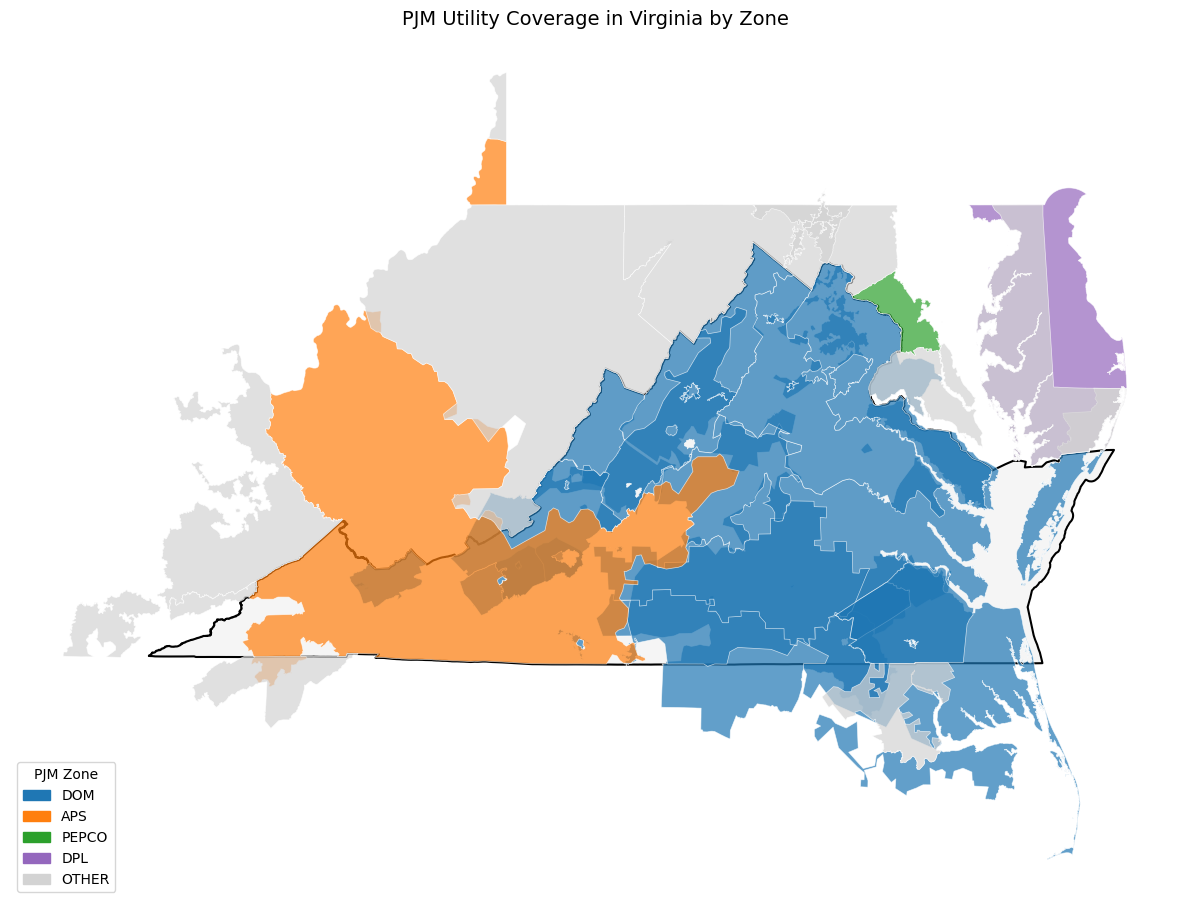

In [13]:
#Plot to check which major utilities are in PJM

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Assign PJM zone to each utility for coloring
# This is a heuristic based on utility names and control areas, as the dataset doesn't explicitly list PJM zones (created by Claude AI)
def assign_zone(row):
    name = row["NameFinal"]
    cntrl = row["CNTRL_AREA"]
    if "Dominion" in name or any(x in name for x in ["BARC", "Rappahannock", "Northern Neck", 
        "Northern Virginia", "Manassas", "Martinsville", "Mecklenburg", "Bedford", 
        "Radford", "Richlands", "Salem", "Shenandoah", "Blackstone", "Wakefield",
        "Southside", "Central Virginia", "Community Electric", "Craig-Botetourt",
        "Culpeper", "Franklin", "Front Royal", "Harrisonburg", "A & N", "Danville",
        "Elkton", "Prince George", "Virginia Tech"]):
        return "DOM"
    elif "Appalachian" in name:
        return "APS"
    elif "Potomac Electric" in name:
        return "PEPCO"
    elif "Delmarva" in name:
        return "DPL"
    else:
        return "OTHER"

virginia_pjm_utilities["zone"] = virginia_pjm_utilities.apply(assign_zone, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

# Virginia boundary
virginia.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=1.5)

# Utility territories colored by zone
zone_colors = {
    "DOM":   "#1f77b4",
    "APS":   "#ff7f0e",
    "PEPCO": "#2ca02c",
    "DPL":   "#9467bd",
    "OTHER": "#d3d3d3"
}

for zone, color in zone_colors.items():
    subset = virginia_pjm_utilities[virginia_pjm_utilities["zone"] == zone]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.5, alpha=0.7)

# Legend
patches = [mpatches.Patch(color=c, label=z) for z, c in zone_colors.items()]
ax.legend(handles=patches, title="PJM Zone", loc="lower left", fontsize=10)

ax.set_title("PJM Utility Coverage in Virginia by Zone", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

The result:

We want to get data from zones DOM and APS when downloading PJM data. This matches with data maps published by PJM. 

In [14]:
#Filter to Virginia
virginia_substations_full = substation_data[substation_data["StateShort"] == "VA"]
print(f"Number of substations in Virginia: {len(virginia_substations_full)}")

#Filter to SUBSTATION type only
virginia_substations_full = virginia_substations_full[
    virginia_substations_full["type"] == "SUBSTATION"
]
print(f"Substations after filtering: {len(virginia_substations_full)}")

#Filter out any with unknown in the name
virginia_substations_clean = virginia_substations_full[
    ~virginia_substations_full["Name"].str.upper().str.contains("UNKNOWN", na=False)
]
print(f"Substations after removing unknown names: {len(virginia_substations_clean)}")

#Spatial join to confirm within Virginia boundary
virginia_substations_geo = gpd.sjoin(
    virginia_substations_clean,
    virginia[["geometry"]],
    how="inner",
    predicate="within"
)
print(f"Substations within Virginia boundary: {len(virginia_substations_geo)}")


Number of substations in Virginia: 1432
Substations after filtering: 1097
Substations after removing unknown names: 592
Substations within Virginia boundary: 592


In [15]:
# Preview both name formats
print("Substation names (sample):")
print(virginia_substations_clean["Name"].head(20).tolist())

print("\nPJM pnode names (sample):")
print(sample_hourly_lmp["pnode_name"].unique()[:20])

Substation names (sample):
['Gore', 'Imboden', 'Dorchester', 'Richlands', 'Claypool Hill', 'Sandy Ridge', 'Jewell Ridge', 'Jewell Branch', 'Buckhorn', 'Lonesome Pine', 'Clinchfield', 'Fletchers Ridge', 'Hales Branch', 'Jewell Smokeless C and C Coal Co', 'Shack Mills Station', 'Kean Mtn and Grassy Creek', 'Buchanan Generation LLC', 'Looney Creek', 'Grundy', 'Freemont']

PJM pnode names (sample):
<ArrowStringArray>
[    'PJM-RTO', 'MID-ATL/APS',      'ALDENE',     'ATHENIA',    'BELLEVIL',
    'BENNETTS',    'BRIDGEWA',     'CLIF PS',     'FOUNDRY',    'GREENBRO',
    'HAWTHORN',    'HILLSDAL',     'HOBOKEN',      'KILMER',    'KINGSLAN',
      'LEONIA',    'LAKENELS',     'MINUEST',     'NEWP PS',     'PENHORN']
Length: 20, dtype: str


In [16]:
from rapidfuzz import process, fuzz

substation_names = virginia_substations_geo["Name"].tolist()
pnode_names = sample_hourly_lmp["pnode_name"].unique().tolist()

# One match per substation
results = []
for name in substation_names:
    match, score, idx = process.extractOne(
        name.upper(),
        [p.upper() for p in pnode_names],
        scorer=fuzz.token_sort_ratio
    )
    results.append({
        "substation_name": name,
        "pnode_match": pnode_names[idx],
        "score": score
    })

matches_df = pd.DataFrame(results)

print(f"Total substations: {len(substation_names)}")
print(f"Total matches: {len(matches_df)}")
print(matches_df.sort_values("score", ascending=False).to_string())

Total substations: 592
Total matches: 592
                            substation_name          pnode_match       score
296                                 Dryburg              DRYBURG  100.000000
307                            Joshua Falls         JOSHUA FALLS  100.000000
305                                   Monel                MONEL  100.000000
304                                 Boxwood              BOXWOOD  100.000000
302                                  Midway               MIDWAY  100.000000
301                                Grottoes             GROTTOES  100.000000
300                                   Dooms                DOOMS  100.000000
298                                  Clover               CLOVER  100.000000
291                                   Wurno                WURNO  100.000000
289                                 Huffman              HUFFMAN  100.000000
282                                Franklin             FRANKLIN  100.000000
281                               

In [20]:
from rapidfuzz import process, fuzz

pnode_names = sample_hourly_lmp["pnode_name"].unique().tolist()

# One match per substation, include coordinates from the start
results = []
for _, row in virginia_substations_geo.iterrows():
    match, score, idx = process.extractOne(
        row["Name"].upper(),
        [p.upper() for p in pnode_names],
        scorer=fuzz.token_sort_ratio
    )
    results.append({
        "substation_name": row["Name"],
        "latitude": row["latitude"],
        "longitude": row["longitude"],
        "pnode_match": pnode_names[idx],
        "score": score
    })

matches_df = pd.DataFrame(results)

print(f"Total substations: {len(matches_df)}")
print(matches_df.sort_values("score", ascending=False).to_string())

Total substations: 592
                            substation_name   latitude  longitude          pnode_match       score
296                                 Dryburg  36.820047 -78.736010              DRYBURG  100.000000
307                            Joshua Falls  37.406399 -79.077043         JOSHUA FALLS  100.000000
305                                   Monel  37.456485 -79.124261                MONEL  100.000000
304                                 Boxwood  37.593455 -79.032425              BOXWOOD  100.000000
302                                  Midway  38.026582 -78.707160               MIDWAY  100.000000
301                                Grottoes  38.266069 -78.812819             GROTTOES  100.000000
300                                   Dooms  38.107035 -78.849097                DOOMS  100.000000
298                                  Clover  36.866211 -78.706544               CLOVER  100.000000
291                                   Wurno  37.074693 -80.717405                WURNO

In [21]:
# Export to Excel
output_path = DATA_DIR / "processed" / "substation_pnode_matches.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    matches_df[matches_df["score"] >= 90].sort_values("score", ascending=False).to_excel(
        writer, sheet_name="high_90plus", index=True
    )
    matches_df[(matches_df["score"] >= 70) & (matches_df["score"] < 90)].sort_values("score", ascending=False).to_excel(
        writer, sheet_name="medium_70to90", index=True
    )
    matches_df[(matches_df["score"] >= 50) & (matches_df["score"] < 70)].sort_values("score", ascending=False).to_excel(
        writer, sheet_name="low_50to70", index=True
    )
    matches_df[matches_df["score"] < 50].sort_values("score", ascending=False).to_excel(
        writer, sheet_name="very_low_sub50", index=True
    )

print(f"Exported to {output_path}")
print(f"  high_90plus:    {len(matches_df[matches_df['score'] >= 90])} rows")
print(f"  medium_70to90:  {len(matches_df[(matches_df['score'] >= 70) & (matches_df['score'] < 90)])} rows")
print(f"  low_50to70:     {len(matches_df[(matches_df['score'] >= 50) & (matches_df['score'] < 70)])} rows")
print(f"  very_low_sub50: {len(matches_df[matches_df['score'] < 50])} rows")

Exported to /Users/elenamurray/Documents/Documents/Repositories/MDS_THESIS/Master-Thesis-2026/data/processed/substation_pnode_matches.xlsx
  high_90plus:    239 rows
  medium_70to90:  205 rows
  low_50to70:     130 rows
  very_low_sub50: 18 rows


The next step is to use a combination of Claude AI and manual checks to define the final list of matches. 